<a href="https://colab.research.google.com/github/Vassudev22/EDA-Lab-L41-L42-/blob/main/EXPERIMENT7%20-%2015/9/26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
df = pd.read_csv('video_game_eda_data.csv')
df.head()

,Game_Title,Genre,Platform,Release_Year,Copies_Sold_Millions,Review_Score,Avg_Playtime_Hours
0,Game_1,Shooter,PlayStation,2020,7.27,61,37
1,Game_2,Simulation,Nintendo Switch,2018,9.77,65,137
2,Game_3,Sports,PC,2024,8.06,75,61
3,Game_4,Simulation,Xbox,2023,7.04,75,92
4,Game_5,Simulation,Xbox,2025,2.68,97,120


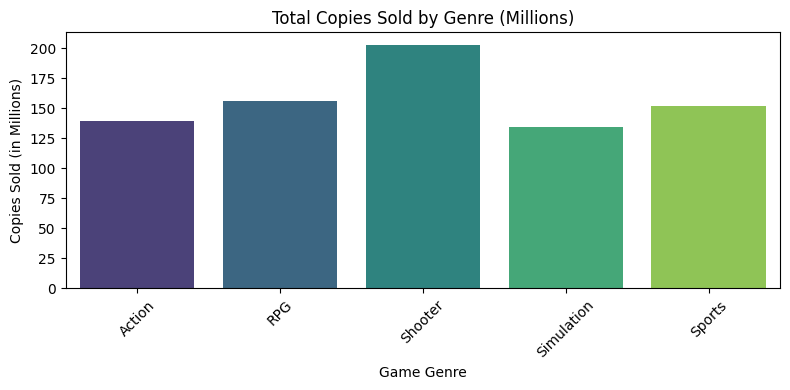

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_sales = df.groupby('Genre')['Copies_Sold_Millions'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=genre_sales, x='Genre', y='Copies_Sold_Millions', hue='Genre', legend=False, palette='viridis')

plt.title("Total Copies Sold by Genre (Millions)")
plt.xlabel("Game Genre")
plt.ylabel("Copies Sold (in Millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


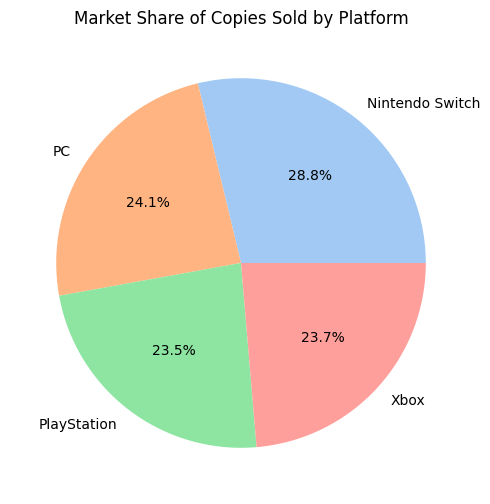

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

platform_sales = df.groupby('Platform')['Copies_Sold_Millions'].sum()
plt.figure(figsize=(6, 6))
plt.pie(platform_sales, labels=platform_sales.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Market Share of Copies Sold by Platform")
plt.show()


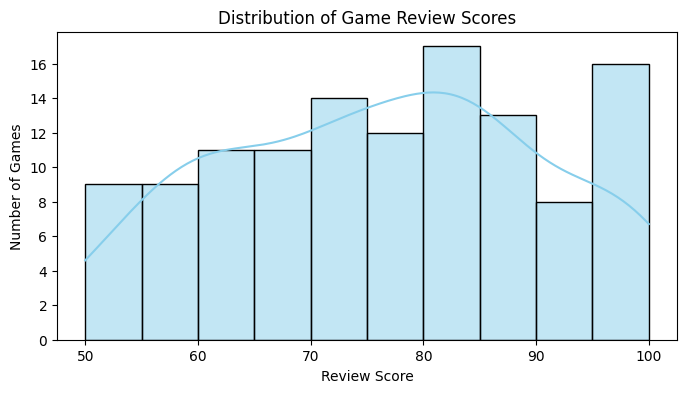

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Review_Score', bins=10, kde=True, color='skyblue')
plt.title("Distribution of Game Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Games")
plt.show()


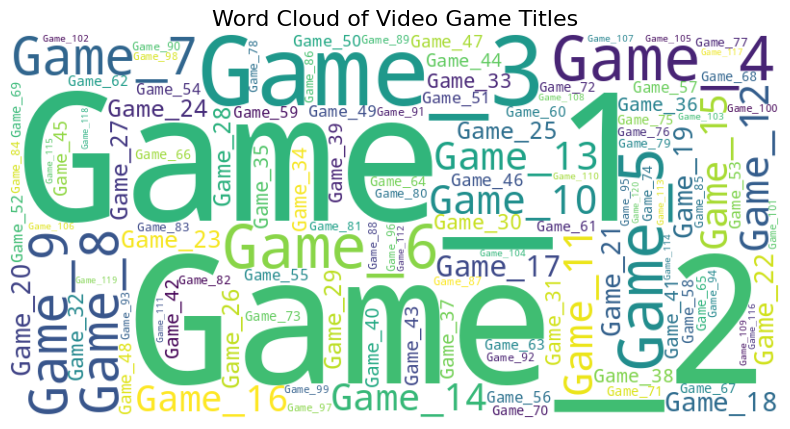

In [13]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

text = " ".join(title for title in df['Game_Title'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Video Game Titles", fontsize=16)
plt.show()


In [14]:
import plotly.express as px
fig = px.treemap(
    df,
    path=['Platform', 'Genre', 'Game_Title'],
    values='Copies_Sold_Millions',
    color='Review_Score',
    color_continuous_scale='RdYlGn',
    title="Interactive Sales Distribution Hierarchy (Size = Sales, Color = Review Score)"
)
fig.show()


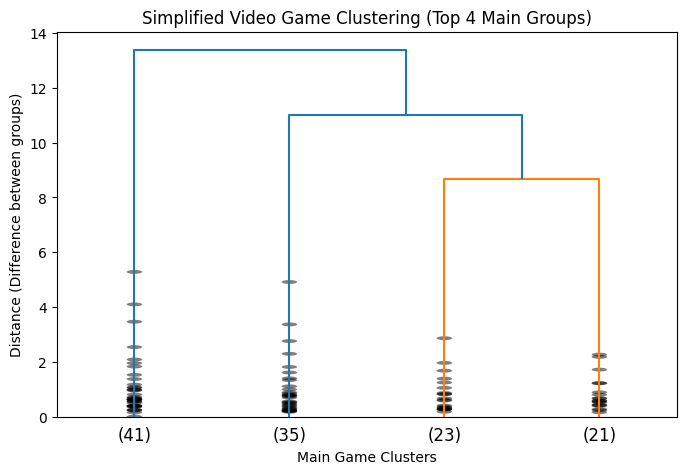

In [16]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
features = df[['Copies_Sold_Millions', 'Review_Score', 'Avg_Playtime_Hours']]
scaled_features = StandardScaler().fit_transform(features)
linked = linkage(scaled_features, method='ward')

plt.figure(figsize=(8, 5))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=4,
    show_contracted=True
)

plt.title("Simplified Video Game Clustering (Top 4 Main Groups)")
plt.xlabel("Main Game Clusters")
plt.ylabel("Distance (Difference between groups)")
plt.show()


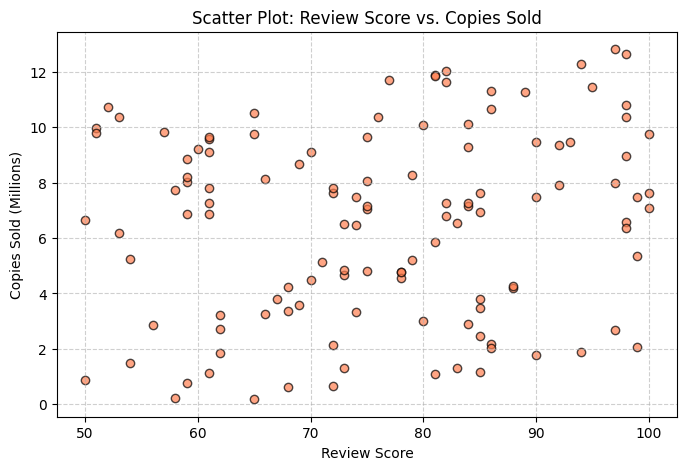

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(df['Review_Score'], df['Copies_Sold_Millions'], color='coral', alpha=0.7, edgecolors='black')
plt.title("Scatter Plot: Review Score vs. Copies Sold")
plt.xlabel("Review Score")
plt.ylabel("Copies Sold (Millions)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


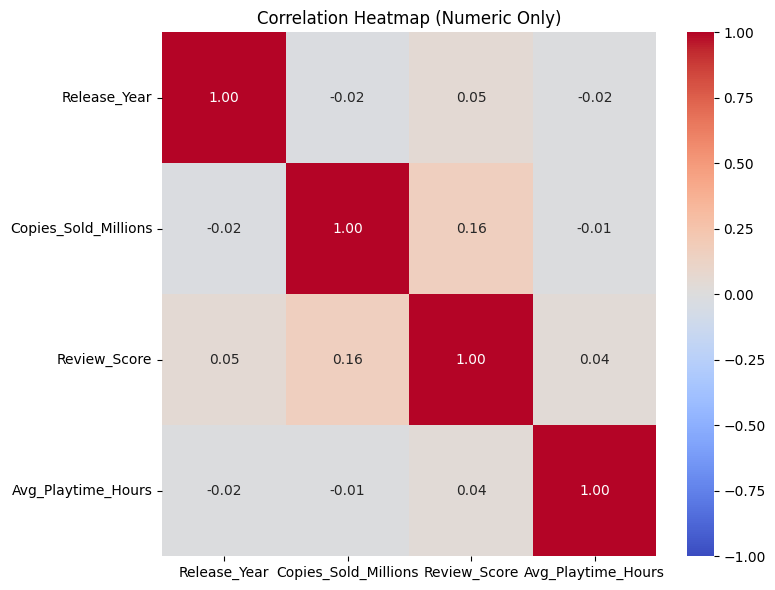

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Numeric Only)")
plt.tight_layout()
plt.show()


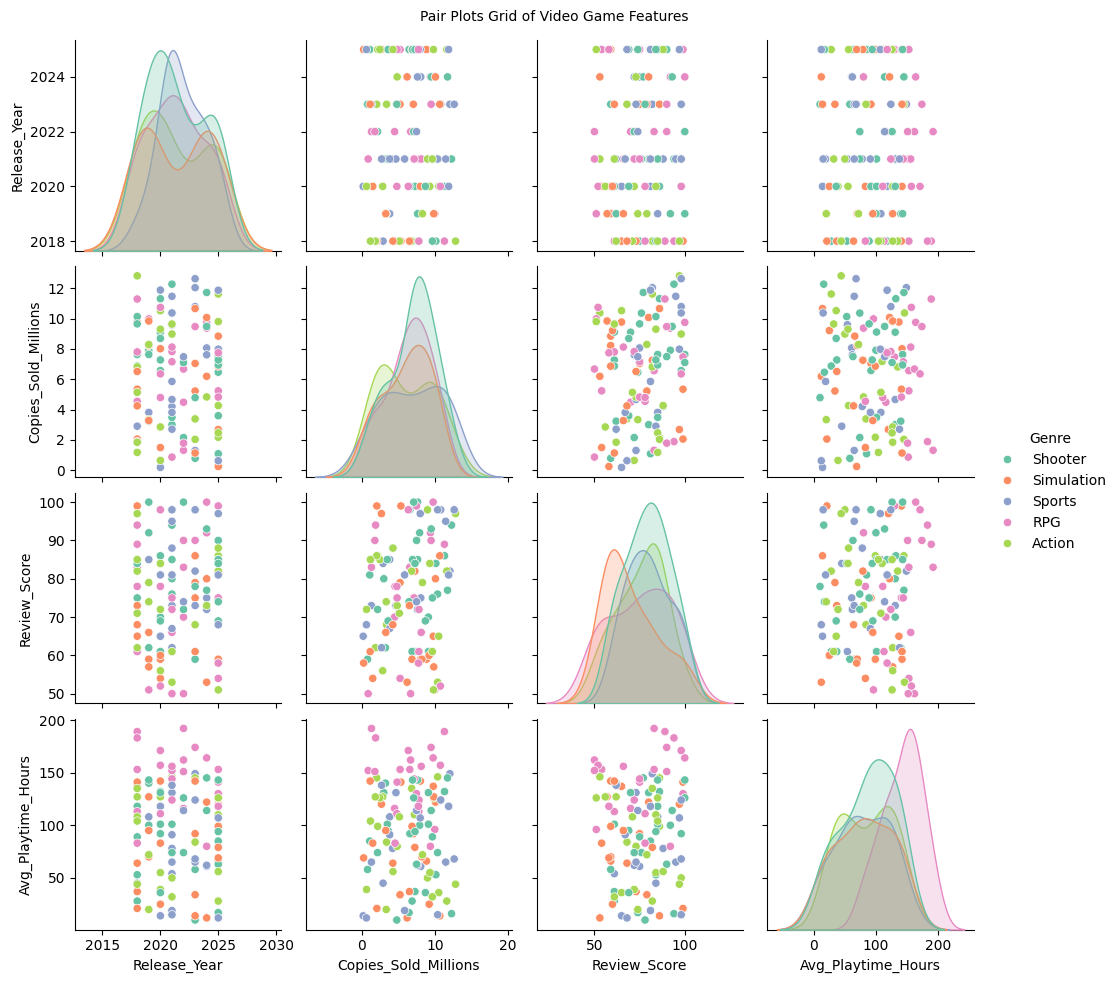

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
pair_grid = sns.pairplot(df, hue='Genre', palette='Set2')
plt.subplots_adjust(top=0.95)
pair_grid.fig.suptitle("Pair Plots Grid of Video Game Features", fontsize=10)
plt.show()


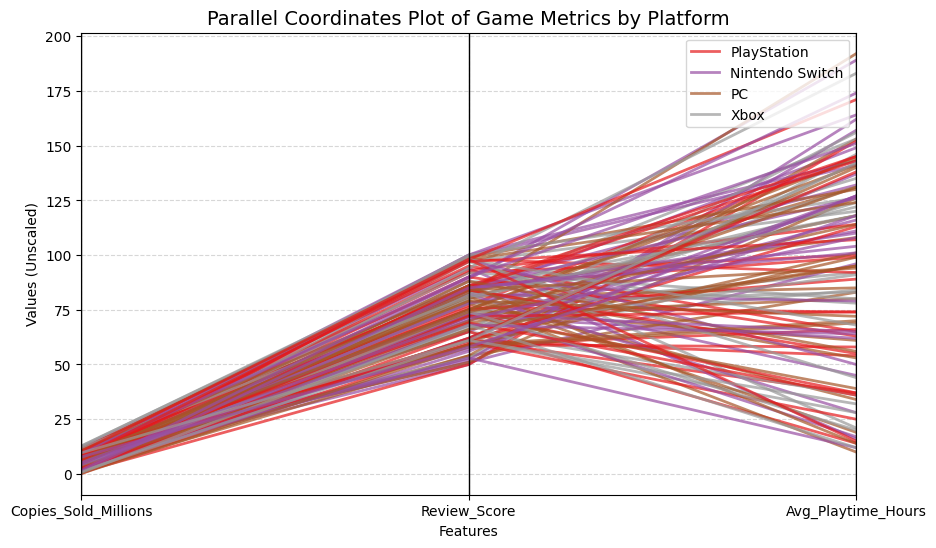

In [20]:
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
plot_columns = ['Platform', 'Copies_Sold_Millions', 'Review_Score', 'Avg_Playtime_Hours']
df_subset = df[plot_columns]
plt.figure(figsize=(10, 6))
parallel_coordinates(df_subset, class_column='Platform', colormap='Set1', linewidth=2, alpha=0.7)
plt.title("Parallel Coordinates Plot of Game Metrics by Platform", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Values (Unscaled)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


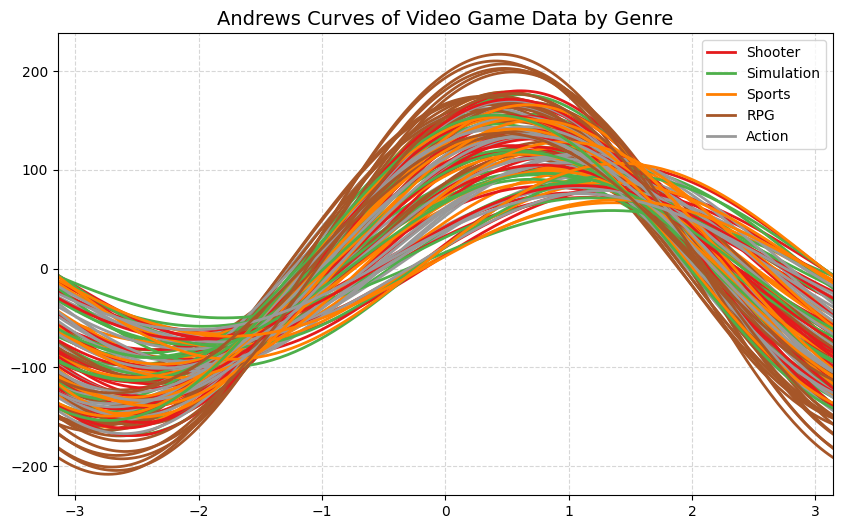

In [21]:
import matplotlib.pyplot as plt
from pandas.plotting import andrews_curves
plot_columns = ['Genre', 'Copies_Sold_Millions', 'Review_Score', 'Avg_Playtime_Hours']
df_subset = df[plot_columns]
plt.figure(figsize=(10, 6))
andrews_curves(df_subset, class_column='Genre', colormap='Set1', linewidth=2)
plt.title("Andrews Curves of Video Game Data by Genre", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
